## ResNet

### 라이브러리 호출

In [ ]:
# 필요한 라이브러리 호출
import torch
import torch.utils.data as data
import torch.nn as nn # 네트워크
import torch.nn.functional as F
import torch.optim as optim # 경사하강법을 위한 옵티마이저 라이브러리
import torchvision
import torchvision.transforms as transforms # 이미지 전처리 라이브러리
import torchvision.datasets as datasets
import torchvision.models as models

import os # 파일 경로 함수
import cv2 # ndarray 타입으로 이미지를 읽고, 관련 처리하는 걸 도와주는 라이브러리
from PIL import Image # 이미지 파일 다루는 걸 도와주는 라이브러리
from torch.utils.data import DataLoader, Dataset
import random
import copy
import time
from collections import namedtuple # namedtuple: 파이썬 자료형 (딕셔너리+튜플)
## 딕셔너리 -> 키를 통한 접근 / 튜플 -> 인덱스를 통한 접근

from matplotlib import pyplot as plt
import numpy as np

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

### 데이터 전처리 및 불러오기

In [ ]:
# 이미지 데이터 전처리
class ImageTransform():
  def __init__(self, resize, mean, std):
    # torchvision 라이브러리를 이용한 이미지 전처리
    self.data_transform = {
        # 학습용 이미지 데이터
        'train': transforms.Compose([
            transforms.RandomResizedCrop(resize, scale=(0.5, 1.0)),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize(mean, std)
        ]),
        # 평가용 이미지 데이터
        'val': transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(resize),
            transforms.ToTensor(),
            transforms.Normalize(mean, std)
        ])
    }

  def __call__(self, img, phase):
    return self.data_transform[phase](img)

In [ ]:
# 데이터 전처리 변수 값 정의
size=224
mean=(0.485, 0.456, 0.406)
std=(0.229, 0.224, 0.225)
batch_size=32

In [ ]:
# 훈련 테스트 데이터셋 불러오기
cat_directory = r'/content/drive/MyDrive/Euron Homework/dataset/dogs-vs-cats/Cat'
dog_directory = r'/content/drive/MyDrive/Euron Homework/dataset/dogs-vs-cats/Dog'

cat_images_filepaths = sorted([os.path.join(cat_directory, f) for f in os.listdir(cat_directory)])
dog_images_filepaths = sorted([os.path.join(dog_directory, f) for f in os.listdir(dog_directory)])

images_filepaths = [*cat_images_filepaths, *dog_images_filepaths] # 개 이미지 + 고양이 이미지
correct_images_filepaths = [i for i in images_filepaths if cv2.imread(i) is not None] # 이미지 파일 불러오기

In [ ]:
# 데이터셋 분리
random.seed(42)
random.shuffle(correct_images_filepaths)
train_images_filepaths = correct_images_filepaths[:400] # train - 400
val_images_filepaths = correct_images_filepaths[400:-10] # val - 92
test_images_filepaths = correct_images_filepaths[-10:] # test - 10
print(len(train_images_filepaths), len(val_images_filepaths), len(test_images_filepaths))

400 92 10


In [ ]:
# 이미지에 대한 레이블 구분 - 전처리 적용
class DogvsCatDataset(Dataset):
  def __init__(self, file_list, transform=None, phase='train'):
    self.file_list=file_list # 이미지 데이터가 위치한 파일 경로
    self.transform=transform # 이미지 데이터 전처리
    self.phase=phase # 'train' 또는 'val'

  def __len__(self):
    return len(self.file_list) # 파일들의 개수를 반환하게 함

  def __getitem__(self, idx):
    img_path=self.file_list[idx] # 이미지 데이터 인덱스(경로) 가져오기
    img = Image.open(img_path)
    img_transformed=self.transform(img, self.phase)

    label = img_path.split('/')[-1].split('.')[0] # 레이블 값 가져오기
    ## 경로로 잘랐을 때의 마지막 단어 -> 확장자 자른 문자열을 들고온 것
    if label == 'dog':
      label=1
    elif label == 'cat':
      label=0

    return img_transformed, label # 전처리 적용된 이미지, 레이블 반환

In [ ]:
# 훈련, 검증, 평가 이미지 데이터셋 정의
train_dataset = DogvsCatDataset(train_images_filepaths, transform=ImageTransform(size, mean, std), phase='train')
val_dataset = DogvsCatDataset(val_images_filepaths, transform=ImageTransform(size, mean, std), phase='val')
test_dataset = DogvsCatDataset(test_images_filepaths, transform=ImageTransform(size, mean, std), phase='val') # filepath 오타?

index=0
print(train_dataset.__getitem__(index)[0].size()) # 이미지 크기
print(train_dataset.__getitem__(index)[1]) # 레이블

index=2
print(train_dataset.__getitem__(index)[0].size()) # 이미지 크기
print(train_dataset.__getitem__(index)[1]) # 레이블

torch.Size([3, 224, 224])
0
torch.Size([3, 224, 224])
1


0: 고양이, 1: 개

In [ ]:
# 데이터셋의 데이터를 메모리로 불러오기
train_iterator = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_iterator = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
dataloader_dict = {'train':train_iterator, 'val':valid_iterator}

# 배치 단위로 불러옴
batch_iterator = iter(train_iterator)
inputs, label = next(batch_iterator)
print(inputs.size())
print(label)

torch.Size([32, 3, 224, 224])
tensor([0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0,
        1, 0, 0, 1, 0, 0, 0, 1])


### 기본 블록, 병목 블록 정의

In [ ]:
# 기본 블록 정의
class BasicBlock(nn.Module):
  expansion=1

  def __init__(self, in_channels, out_channels, stride=1, downsample=False):
    super().__init__()
    # 3x3 conv
    self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
    self.bn1 = nn.BatchNorm2d(out_channels)
    self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
    self.bn2 = nn.BatchNorm2d(out_channels)
    self.relu == nn.ReLU(inplace=True)

    # 다운샘플 적용: 입력 피처맵의 크기와 출력 피처맵의 크기가 다를 경우 사용
    if downsample:
      # stride 적용
      conv = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False)
      bn = nn.BatchNorm2d(out_channels)
      downsample = nn.Sequential(conv, bn)
    else:
      downsample = None
    self.downsample=downsample

  def forward(self, x):
    i=x
    x=self.conv1(x)
    x=self.bn1(x)
    x=self.relu(x)
    x=self.conv2(x)
    x=self.bn2(2)

    if self.downsample is not None:
      i = self.downsample(i) # 아이덴티티 매핑 적용을 위해서

    x += i # 아이덴티티 매핑 적용
    x=self.relu(x)
    return x

In [ ]:
# 병목 블록 정의
class Bottleneck(nn.Module):
  expansion = 4 # ResNet에서 병목 블록을 정의하기 위한 하이퍼파라미터

  def __init__(self, in_channels, out_channels, stride=1, downsample=False):
    super().__init__()
    self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, # 1x1
                           stride=1, bias=False)
    self.bn1 = nn.BatchNorm2d(out_channels)
    self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, # 3x3
                           stride=stride, padding=1, bias=False)
    self.bn2 = nn.BatchNorm2d(out_channels)
    self.conv3 = nn.Conv2d(out_channels, self.expansion*out_channels, kernel_size=1, # 1x1
                           stride=1, bias=False)
    ## 다음 계층 입력 채널 수(깊이)랑 맞추기 위해 self.expansion*out_channels
    self.bn3 = nn.BatchNorm2d(self.expansion*out_channels)
    self.relu = nn.ReLU(inplace=True)

    if downsample:
      # stride 적용
      conv = nn.Conv2d(in_channels, self.expansion*out_channels, kernel_size=1,
                       stride=stride, bias=False)
      bn = nn.BatchNorm2d(self.expansion*out_channels)
      downsample = nn.Sequential(conv, bn)
    else:
      downsample = None
    self.downsample=downsample

  def forward(self, x):
    i=x
    x=self.conv1(x)
    x=self.bn1(x)
    x=self.relu(x)
    x=self.conv2(x)
    x=self.bn2(x)
    x=self.relu(x)
    x=self.conv3(x)
    x=self.bn3(x)

    if self.downsample is not None:
      i = self.downsample(i)

    x += i # 아이덴티티 매핑
    x=self.relu(x)
    return x

병목 블록
- 계층을 더 깊게 쌓으면서 계산에 대한 비용을 줄여줌
- 계층⬆️ -> 활성화 함수가 기존보다 더 많이 포함됨 -> 더 많은 비선형성 처리 => 다양한 입력 데이터에 대한 처리 가능

### ResNet 네트워크 구성

In [ ]:
class ResNet(nn.Module):
  def __init__(self, config, output_dim, zero_init_residual=False):
    super().__init__()

    block, n_blocks, channels = config # ResNet을 호출할 때 넘겨준 config 값들
    self.in_channels = channels[0]
    assert len(n_blocks) == len(channels) == 4 # 예외처리문: 뒤의 조건은 항상 참

    self.conv1 = nn.Conv2d(3, self.in_channels, kernel_size=7, stride=2, padding=3, bias=False)
    self.bn1 = nn.BatchNorm2d(self.in_channels)
    self.relu = nn.ReLU(inplace=True)
    self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

    self.layer1 = self.get_resnet_layer(block, n_blocks[0], channels[0])
    self.layer2 = self.get_resnet_layer(block, n_blocks[1], channels[1], stride=2)
    self.layer3 = self.get_resnet_layer(block, n_blocks[2], channels[2], stride=2)
    self.layer4 = self.get_resnet_layer(block, n_blocks[3], channels[3], stride=2)

    self.avgpool = nn.AdaptiveAvgPool2d((1,1))
    self.fc = nn.Linear(self.in_channels, output_dim)

    # 각 residual branch(분기)에 있는 마지막 BN을 0으로 초기화해 다음 분기를 0에서 시작할 수 있도록 함
    ## BN을 0으로 초기화하는 이유: 모델 성능이 0.2~0.3% 정도 향상되기 때문
    if zero_init_residual:
      for m in self.modules():
        if isinstance(m, Bottleneck):
          nn.init_constant_(m.bn3.weight, 0) # 병목이면 bn3이 마지막
        elif isinstance(m, BasicBlock):
          nn.init_constant_(m.bn2.weight, 0) # 기본이면 bn2가 마지막

  def get_resnet_layer(self, block, n_blocks, channels, stride=1): # 블록 추가 함수
    layers = []
    if self.in_channels != block.expansion * channels:
      downsample=True # 차원 맞춰야 함
    else:
      downsample=False

    layers.append(block(self.in_channels, channels, stride, downsample))
    for i in range(1, n_blocks): # n_blocks만큼 계층 추가
      layers.append(block(block.expansion*channels, channels))

    self.in_channels = block.expansion*channels
    return nn.Sequential(*layers)

  def forward(self, x):
    x = self.conv1(x) # 224x224
    x = self.bn1(x)
    x = self.relu(x)
    x = self.maxpool(x) # 112x112
    x = self.layer1(x) # 56x56
    x = self.layer2(x) # 28x28
    x = self.layer3(x) # 14x14
    x = self.layer4(x) # 7x7
    x = self.avgpool(x) # 1x1
    h = x.view(x.shape[0], -1) # 1차원 벡터
    x = self.fc(h)
    return x, h

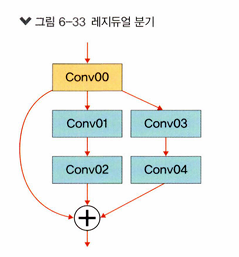

In [ ]:
# ResNetConfig 정의
ResNetConfig = namedtuple('ResNetConfig', ['block', 'n_blocks', 'channels'])

In [ ]:
# 기본 블록을 사용하는 ResNetConfig 정의
resnet18_config = ResNetConfig(block=BasicBlock,
                         n_blocks=[2,2,2,2],
                         channels=[64,128,256,512])
resnet34_config = ResNetConfig(block=BasicBlock,
                         n_blocks=[3,4,6,3],
                         channels=[64,128,256,512])

In [ ]:
# 병목 블록을 사용하는 ResNetConfig 정의
resnet50_config = ResNetConfig(block=Bottleneck,
                         n_blocks=[3,4,6,3],
                         channels=[64,128,256,512])

resnet101_config = ResNetConfig(block=Bottleneck,
                         n_blocks=[3,4,23,3],
                         channels=[64,128,256,512])

resnet152_config = ResNetConfig(block=Bottleneck,
                         n_blocks=[3,8,36,3],
                         channels=[64,128,256,512])

In [ ]:
# (직접 구현하지 않고) 사전 훈련된 ResNet 모델 사용
pretrained_model = models.resnet50(pretrained=True)

In [ ]:
print(pretrained_model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:
# ResNet50 Config를 사용한 ResNet 모델 사용
OUTPUT_DIM=2 # 클래스 2개 (개 고양이)
model = ResNet(resnet50_config, OUTPUT_DIM)
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

직접 정의한 네트워크와 사전 정의된 네트워크가 동일함

단 사전 훈련된 모델을 사용하는 경우 논문의 구조랑 코드를 꼭 살펴보고 사용하자!

### 모델 학습

In [ ]:
# 옵티마이저와 손실 함수 정의
optimizer = optim.Adam(model.parameters(), lr=1e-7)
criterion = nn.CrossEntropyLoss()

model = model.to(device)
criterion = criterion.to(device)

In [ ]:
# 모델 학습 정확도 측정 함수 정의
def calculate_topk_accuracy(y_pred, y,k=2):
  with torch.no_grad():
    batch_size = y.shape[0]
    _, top_pred = y_pred.topk(k,1) # torch.argmax와 같은 효과
    ## tensor.topk: top-k 반환 (largest=False로 주면 smallest-k 반환)
    ## y_pred.topk: 네트워크 출력(예측값)에서 가장 확률이 높은 값의 인덱스 반환
    top_pred = top_pred.t() # transpose
    correct = top_pred.eq(y.view(1, -1).expand_as(top_pred)) # 예측값 & 정답 비교
    ## torch.eq, torch.ne, torch.ge (비교 대상 텐서, 비교할 텐서)
    ## 각 요소를 비교해서 같으면 True, 다르면 False를 요소로 넣은 텐서를 반환
    ## torch.Tensor.expand_as() == Tensor.expand(other.size())
    correct_1 = correct[:1].reshape(-1).float().sum(0, keepdim=True)
    correct_k = correct[:k].reshape(-1).float().sum(0, keepdim=True) # k번째 예측값
    acc_1 = correct_1 / batch_size
    acc_k = correct_k / batch_size
  return acc_1, acc_k

In [ ]:
# 모델 학습 함수 정의
def train(model, iterator, optimizer, criterion, scheduler, device):
## scheduler: 보통 torch.optim.lr_scheduler.StepLR 등으로 학습률까지 조정하기 위해 쓰임
  epoch_loss=0
  epoch_acc_1=0
  epoch_acc_5=0

  model.train() # nn.Module.train()
  for(x,y) in iterator:
    x=x.to(device)
    y=y.to(device)

    optimizer.zero_grad()
    y_pred=model(x)
    loss=criterion(y_pred[0], y)

    # k 디폴트 값이 2인데 왜 acc_5지?
    acc_1, acc_5 = calculate_topk_accuracy(y_pred[0], y)
    loss.backward()
    optimizer.step()

    epoch_loss += loss.item()
    epoch_acc_1 += acc_1.item() # 모델이 첫 번째로 예측한 레이블
    epoch_acc_5 += acc_5.item()

  epoch_loss /= len(iterator) # 평균 계산
  epoch_acc_1 /= len(iterator)
  epoch_acc_5 /= len(iterator)
  return epoch_loss, epoch_acc_1, epoch_acc_5

In [ ]:
# 모델 평가 함수 정의
def evaluate(model, iterator, criterion, device):
  epoch_loss=0
  epoch_acc_1=0
  epoch_acc_5=0

  model.eval() # nn.Module.eval()
  with torch.no_grad():
    for (x,y) in iterator:
      x=x.to(device)
      y=y.to(device)
      y_pred=model(x)
      loss=criterion(y_pred[0], y)

      acc_1, acc_5 = calculate_topk_accuracy(y_pred[0], y)
      epoch_loss += loss.item()
      epoch_acc_1 += acc_1.item() # 모델이 첫 번째로 예측한 레이블
      epoch_acc_5 += acc_5.item()

  epoch_loss /= len(iterator) # 평균 계산
  epoch_acc_1 /= len(iterator)
  epoch_acc_5 /= len(iterator)
  return epoch_loss, epoch_acc_1, epoch_acc_5

In [ ]:
# 모델 학습 시간 측정 함수
def epoch_time(start_time, end_time):
  elapsed_time = end_time-start_time
  elapsed_mins = int(elapsed_time/60)
  elapsed_secs = int(elapsed_time-(elapsed_mins*60))
  return elapsed_mins, elapsed_secs

In [ ]:
# 모델 학습
best_valid_loss = float('inf')
EPOCHS = 10

for epoch in range(EPOCHS):
  start_time = time.monotonic()
  train_loss, train_acc_1, train_acc_5 = train(model, train_iterator, optimizer, criterion,
                                               scheduler=None, device=device)
  valid_loss, valid_acc_1, valid_acc_5 = evaluate(model, valid_iterator, criterion, device)

  if valid_loss < best_valid_loss:
    best_valid_loss = valid_loss
    torch.save(model.state_dict(), '/content/drive/MyDrive/Euron Homework/dataset/ResNet-model.pt')

  end_time = time.monotonic()
  epoch_mins, epoch_secs = epoch_time(start_time, end_time)

  print(f'Epoch: {epoch+1:02} | Epoch Time: {epoch_mins}m {epoch_secs}s')
  print(f'\tTrain Loss: {train_loss:.3f} | Train Acc @1: {train_acc_1*100:6.2f}% | '\
        f'Train Acc @5: {train_acc_5*100:6.2f}%')
  print(f'\tValid Loss: {valid_loss:.3f} | Valid Acc @1: {valid_acc_1*100:6.2f}% | '\
        f'Valid Acc @5: {valid_acc_5*100:6.2f}%')

Epoch: 01 | Epoch Time: 0m 7s
	Train Loss: 0.691 | Train Acc @1:  56.49% | Train Acc @5: 100.00%
	Valid Loss: 0.677 | Valid Acc @1:  65.03% | Valid Acc @5: 100.00%
Epoch: 02 | Epoch Time: 0m 11s
	Train Loss: 0.684 | Train Acc @1:  58.65% | Train Acc @5: 100.00%
	Valid Loss: 0.672 | Valid Acc @1:  62.05% | Valid Acc @5: 100.00%
Epoch: 03 | Epoch Time: 0m 7s
	Train Loss: 0.689 | Train Acc @1:  55.05% | Train Acc @5: 100.00%
	Valid Loss: 0.666 | Valid Acc @1:  64.29% | Valid Acc @5: 100.00%
Epoch: 04 | Epoch Time: 0m 9s
	Train Loss: 0.681 | Train Acc @1:  60.34% | Train Acc @5: 100.00%
	Valid Loss: 0.668 | Valid Acc @1:  55.21% | Valid Acc @5: 100.00%
Epoch: 05 | Epoch Time: 0m 8s
	Train Loss: 0.684 | Train Acc @1:  58.17% | Train Acc @5: 100.00%
	Valid Loss: 0.670 | Valid Acc @1:  57.59% | Valid Acc @5: 100.00%
Epoch: 06 | Epoch Time: 0m 7s
	Train Loss: 0.683 | Train Acc @1:  56.25% | Train Acc @5: 100.00%
	Valid Loss: 0.675 | Valid Acc @1:  55.65% | Valid Acc @5: 100.00%
Epoch: 07 | Epo

데이터가 적어서 성능은 별로 좋지 않음

### 예측

In [ ]:
# 테스트 데이터셋을 이용한 모델 예측
import pandas as pd
id_list=[]
pred_list=[]
_id = 0
with torch.no_grad():
  for test_path in test_images_filepaths:
    img = Image.open(test_path)
    _id = test_path.split('/')[-1].split('.')[1]
    transform = ImageTransform(size, mean, std) # 전처리
    img = transform(img, phase='val')
    img = img.unsqueeze(0)
    img = img.to(device)

    model.eval()
    outputs = model(img)
    preds = F.softmax(outputs[0], dim=1)[:,1].tolist()
    id_list.append(_id)
    pred_list.append(preds[0])

res = pd.DataFrame({
    'id': id_list,
    'label': pred_list
})

res.sort_values(by='id', inplace=True)
res.reset_index(drop=True, inplace=True)

res.to_csv('/content/drive/MyDrive/Euron Homework/dataset/ResNet.csv', index=False)
res.head(10)

,id,label
0,109,0.486468
1,145,0.492725
2,15,0.538034
3,162,0.483580
4,167,0.466563
5,200,0.551378
6,210,0.513693
7,211,0.513452
8,213,0.444895
9,224,0.468246


In [ ]:
# 모델 예측 결과 출력
class_ = classes = {0:'cat', 1:'dog'}
def display_image_grid(images_filepaths, predicted_labels=(), cols=5):
  rows=len(images_filepaths) // cols
  figure, ax = plt.subplots(nrows=rows, ncols=cols, figsize=(12,6))
  for i, image_filepath in enumerate(images_filepaths):
    image = cv2.imread(image_filepath)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    a = random.choice(res['id'].values)
    label = res.loc[res['id']==a, 'label'].values[0]
    if label > 0.5:
      label = 1
    else:
      label = 0

    ax.ravel()[i].imshow(image)
    ax.ravel()[i].set_title(class_[label])
    ax.ravel()[i].set_axis_off()
  plt.tight_layout()
  plt.show()

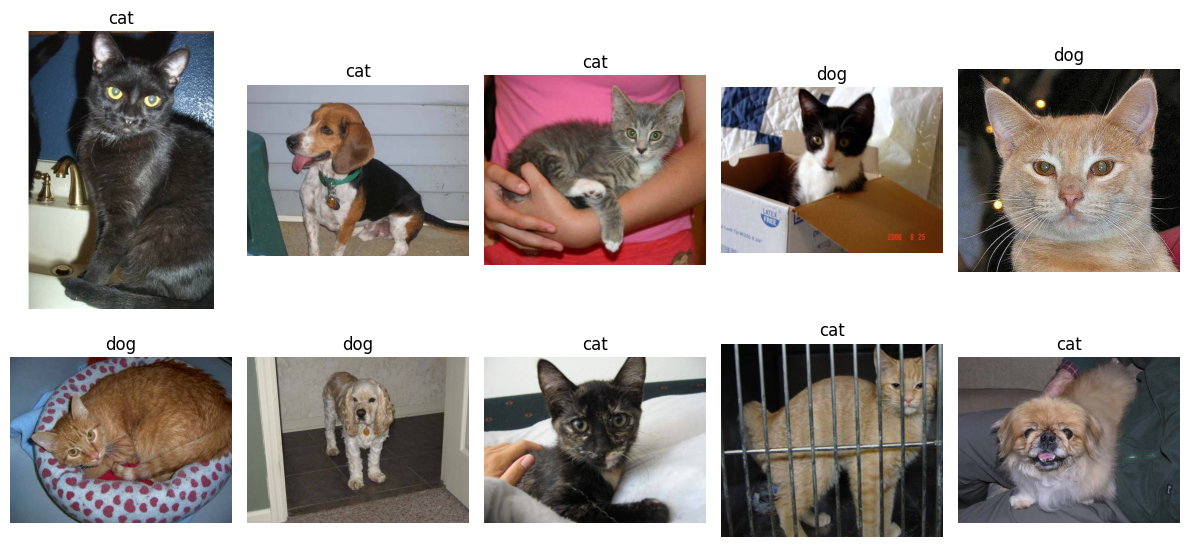

In [ ]:
display_image_grid(test_images_filepaths)